In [24]:
import os, re, random
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from scipy.stats import chi2 as chi2_dist
from collections import defaultdict

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATE        = "20250702"          # YYYYMMDD
SVD_DIR     = "/home/zhe2/data/PACE/svd_retrieval_output"
L2AOP_DIR   = "/home/zhe2/data/PACE/L2_AOP_V3.1"
L2BGC_DIR   = "/home/zhe2/data/PACE/L2_BGC_V3.1"
L1B_DIR     = "/home/zhe2/data/PACE/L1B_V3"

# Fitting / display window
LAMBDA_MIN, LAMBDA_MAX = 640.0, 756.0   # nm
CHI2_XLIM   = (0, 10)
CHI2_NBINS  = 200
DF_THEORY   = 60                      # reduced-chi² dof for theoretical bounds
MAX_MEAN_RAD = 30.0                   # W m⁻² sr⁻¹ µm⁻¹ (ocean-like filter)

# ── FILE DISCOVERY ────────────────────────────────────────────────────────────
SVD_RE   = re.compile(r"^interim_(\d{8}T\d{6})_svd_retrieval_.*\.nc$")
L2AOP_RE = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L2\.OC_AOP.*\.nc$")
L2BGC_RE = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L2\.OC_BGC.*\.nc$")
L1B_RE   = re.compile(r"^PACE_OCI\.(\d{8}T\d{6})\.L1B\.")

svd_files = sorted(
    os.path.join(SVD_DIR, f)
    for f in os.listdir(SVD_DIR)
    if SVD_RE.match(f) and f.startswith(f"interim_{DATE}")
)

def _index_by_gid(directory, regex):
    idx = {}
    for fn in os.listdir(directory):
        m = regex.match(fn)
        if m:
            idx[m.group(1)] = os.path.join(directory, fn)
    return idx

l2aop_idx = _index_by_gid(L2AOP_DIR, L2AOP_RE)
l2bgc_idx = _index_by_gid(L2BGC_DIR, L2BGC_RE)
l1b_idx   = {
    gid: path for gid, path in _index_by_gid(L1B_DIR, L1B_RE).items()
    if gid.startswith(DATE)
}

def _match_gid(idx, gid):
    if gid in idx:
        return idx[gid]
    for k, v in idx.items():
        if k[:-2] == gid[:-2]:
            return v
    return None

def match_l2(gid):
    return _match_gid(l2aop_idx, gid)

def match_bgc(gid):
    return _match_gid(l2bgc_idx, gid)

def match_l1b(gid):
    return _match_gid(l1b_idx, gid)

print(f"Found {len(svd_files)} SVD files for {DATE}")
print(f"  L2 AOP index: {len(l2aop_idx):,}  |  L2 BGC: {len(l2bgc_idx):,}  |  L1B({DATE}): {len(l1b_idx):,}")


Found 147 SVD files for 20250702
  L2 AOP index: 4,802  |  L2 BGC: 4,802  |  L1B(20250702): 147


In [25]:
# ── LOAD ALL GRANULES ─────────────────────────────────────────────────────────
chi2_all   = []   # all pixels
stat_all   = []   # status code per pixel
flag_all   = []   # l2_flags (0 = clean) per pixel
nflh_all   = []   # nFLH valid boolean per pixel

for svd_path in svd_files:
    m   = SVD_RE.match(os.path.basename(svd_path))
    gid = m.group(1)
    l2_path = match_l2(gid)

    with nc.Dataset(svd_path, "r") as ds:
        chi2 = np.array(ds["reduced_chi2"][:]).ravel()
        stat = np.array(ds["status_code"][:]).ravel()

    chi2_all.append(chi2)
    stat_all.append(stat)

    if l2_path:
        with nc.Dataset(l2_path, "r") as ds:
            flags = np.array(ds["geophysical_data/l2_flags"][:]).ravel()
            nflh_var = ds["geophysical_data/nflh"]
            fv = float(nflh_var._FillValue) if hasattr(nflh_var, "_FillValue") else None
            nflh = np.ma.filled(nflh_var[:], np.nan).ravel()
        nflh_ok = np.isfinite(nflh) & (nflh != fv if fv is not None else True)
        flag_all.append(flags)
        nflh_all.append(nflh_ok)
    else:
        flag_all.append(np.full(len(chi2), -1, dtype=np.int32))
        nflh_all.append(np.zeros(len(chi2), dtype=bool))

chi2  = np.concatenate(chi2_all)
stat  = np.concatenate(stat_all)
flags = np.concatenate(flag_all)
nflh_ok = np.concatenate(nflh_all)

print(f"Total pixels: {len(chi2):,}")
print(f"  status=0: {np.sum(stat==0):,}   status=1: {np.sum(stat==1):,}   status>=2: {np.sum(stat>=2):,}")
print(f"  flag=0  : {np.sum(flags==0):,}")
print(f"  nFLH ok : {np.sum(nflh_ok):,}")


Total pixels: 314,639,376
  status=0: 30,803,041   status=1: 169,371,968   status>=2: 114,464,367
  flag=0  : 10,954,476
  nFLH ok : 49,141,188


### 1. Chi² quality diagnostics

Run order in this section:
1. Theoretical reduced-χ² bounds (`CHI2_LO` / `CHI2_HI` for `DF_THEORY`)
2. Summary statistics by retrieval population
3. PDF / CDF of `reduced_chi2` by quality mask
4. Latitudinal profiles of χ² and retention fraction
5. Filter-stack PDF comparison (all → status+χ² → +l2_flags)


In [26]:
# ── THEORETICAL 5–95% range of reduced chi² for various degrees of freedom ────
# For a properly-calibrated retrieval, observed reduced_chi² ≈ chi2(df)/df.
# CHI2_LO / CHI2_HI below are used by later cells.

CHI2_LO, CHI2_HI = chi2_dist.ppf([0.05, 0.95], df=DF_THEORY) / DF_THEORY
print(f"Working theoretical bounds (df={DF_THEORY}): "
      f"p5={CHI2_LO:.4f}, p95={CHI2_HI:.4f}")
print()
print("Theoretical 95% interval of reduced chi² = chi2(df)/df")
print(f"  {'df':>5}  {'5th pct':>9}  {'95th pct':>10}  {'mean (=1)':>10}")
print("  " + "-" * 42)
for df in [20, 30, 40, 50, 60, 80, 100]:
    lo, hi = chi2_dist.ppf([0.05, 0.95], df=df) / df
    mark = "  ← used" if df == DF_THEORY else ""
    print(f"  {df:>5}  {lo:>9.4f}  {hi:>10.4f}  {1.0:>10.4f}{mark}")


Working theoretical bounds (df=60): p5=0.7198, p95=1.3180

Theoretical 95% interval of reduced chi² = chi2(df)/df
     df    5th pct    95th pct   mean (=1)
  ------------------------------------------
     20     0.5425      1.5705      1.0000
     30     0.6164      1.4591      1.0000
     40     0.6627      1.3940      1.0000
     50     0.6953      1.3501      1.0000
     60     0.7198      1.3180      1.0000  ← used
     80     0.7549      1.2735      1.0000
    100     0.7793      1.2434      1.0000


In [27]:
# ── SUMMARY STATISTICS TABLE ──────────────────────────────────────────────────
pcts = [50, 75, 90, 95, 99]
# CHI2_LO / CHI2_HI / DF_THEORY already set in the theoretical-bounds cell above.
print(f"Using chi²(df={DF_THEORY}) 5–95% range: [{CHI2_LO:.4f}, {CHI2_HI:.4f}]")
print()

populations_stat = [
    ((stat == 1),                   "status=1"),
    ((stat == 0) | (stat == 1),     "status=0|1"),
    ((stat == 1) & nflh_ok,         "status=1 & nFLH valid"),
    ((stat == 1) & (flags == 0),    "status=1 & flag=0"),
]

header = f"{'Population':<34} {'N':>10}  {'mean':>6}  {'median':>7}  " + \
         "  ".join(f"p{p:02d}" for p in pcts) + \
         f"  {'<1 (%)':>7}  {'<2 (%)':>7}  {'<5 (%)':>7}"
sep = "-" * len(header)
print(header)

def _print_row(label, vals):
    if len(vals) == 0:
        print(f"{label:<34}  (no data)")
        return
    ps     = np.percentile(vals, pcts)
    ps_str = "  ".join(f"{p:6.2f}" for p in ps)
    print(f"{label:<34} {len(vals):>10,}  {vals.mean():>6.2f}  {np.median(vals):>7.3f}  "
          f"{ps_str}  {100*np.mean(vals<1):>7.1f}  {100*np.mean(vals<2):>7.1f}  "
          f"{100*np.mean(vals<5):>7.1f}")

for mask, label in populations_stat:
    finite = mask & np.isfinite(chi2)
    vals_all      = chi2[finite]
    in_band       = (chi2 >= CHI2_LO) & (chi2 <= CHI2_HI)
    vals_filtered = chi2[finite & in_band]

    print(sep)
    _print_row(label,                     vals_all)
    _print_row(f"  └ chi²∈[{CHI2_LO:.3f},{CHI2_HI:.3f}] (df={DF_THEORY})",
               vals_filtered)
    retained = 100 * len(vals_filtered) / max(len(vals_all), 1)
    print(f"    {'→ retained:':20} {len(vals_filtered):>10,}  ({retained:.1f}% of above)")

print(sep)


Using chi²(df=60) 5–95% range: [0.7198, 1.3180]



Population                                  N    mean   median  p50  p75  p90  p95  p99   <1 (%)   <2 (%)   <5 (%)
------------------------------------------------------------------------------------------------------------------
status=1                           169,371,968    5.43    2.878    2.88    5.53   10.44   17.64   53.91     15.2     36.4     71.7
  └ chi²∈[0.720,1.318] (df=60)     27,160,486    1.00    0.995    1.00    1.15    1.25    1.28    1.31     50.8    100.0    100.0
    → retained:          27,160,486  (16.0% of above)
------------------------------------------------------------------------------------------------------------------
status=0|1                         200,175,009   11.12    2.916    2.92    5.98   14.36   39.54  147.85     15.7     36.7     69.7
  └ chi²∈[0.720,1.318] (df=60)     32,875,206    1.00    0.992    0.99    1.15    1.25    1.28    1.31     51.4    100.0    100.0
    → retained:          32,875,206  (16.4% of above)
-------------------------

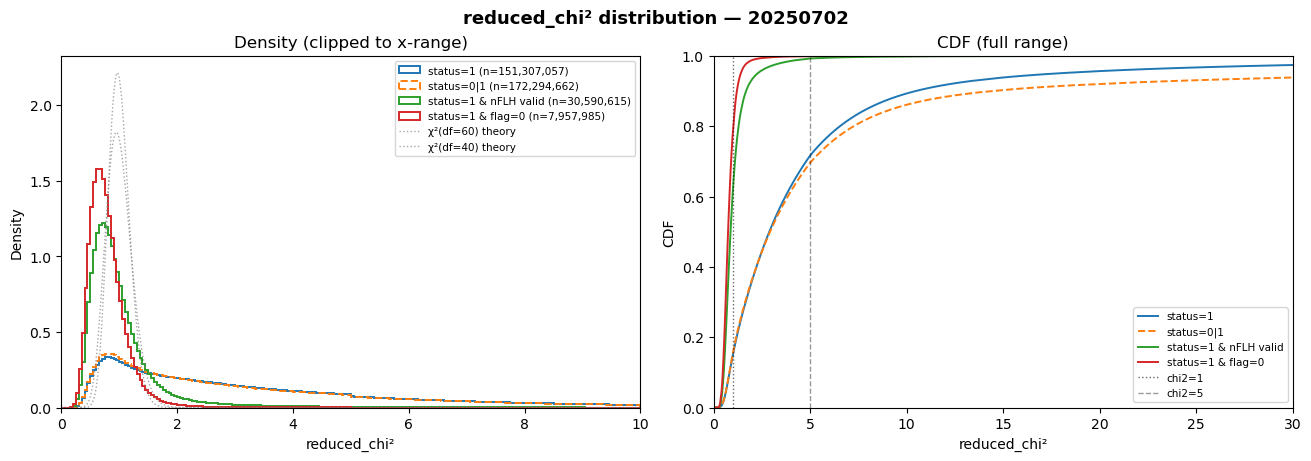

In [28]:
# ── PLOT: reduced_chi2 distribution by quality population ────────────────────
bins = np.linspace(*CHI2_XLIM, CHI2_NBINS + 1)

# Populations (mask, label, color, linestyle)
populations = [
    ((stat == 1),                              "status=1",             "C0",  "-"),
    ((stat == 0) | (stat == 1),                "status=0|1",           "C1",  "--"),
    ((stat == 1) & nflh_ok,                    "status=1 & nFLH valid","C2",  "-"),
    ((stat == 1) & (flags == 0),               "status=1 & flag=0",    "C3",  "-"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
fig.suptitle(f"reduced_chi² distribution — {DATE}", fontsize=13, fontweight="bold")

# --- left: density histogram ---
ax = axes[0]
for mask, label, color, ls in populations:
    vals = chi2[mask & np.isfinite(chi2)]
    vals = vals[(vals >= CHI2_XLIM[0]) & (vals <= CHI2_XLIM[1])]
    ax.hist(vals, bins=bins, density=True, histtype="step",
            color=color, linestyle=ls, linewidth=1.4, label=f"{label} (n={len(vals):,})")

# Theoretical chi2 PDF (df = n_meas - n_state; rough estimate df~60)
for df, ls in [(60, ":"), (40, ":")]:
    x = np.linspace(0.01, CHI2_XLIM[1], 500)
    y = chi2_dist.pdf(x * df, df=df) * df   # transform back to reduced chi2
    ax.plot(x, y, color="gray", linestyle=ls, linewidth=1, alpha=0.7,
            label=f"χ²(df={df}) theory")

ax.set_xlabel("reduced_chi²")
ax.set_ylabel("Density")
ax.set_xlim(CHI2_XLIM)
ax.legend(fontsize=7.5, loc="upper right")
ax.set_title("Density (clipped to x-range)")

# --- right: CDF ---
ax = axes[1]
for mask, label, color, ls in populations:
    vals = np.sort(chi2[mask & np.isfinite(chi2)])
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, color=color, linestyle=ls, linewidth=1.4, label=label)

ax.axvline(1.0, color="k", linestyle=":", linewidth=1, alpha=0.6, label="chi2=1")
ax.axvline(5.0, color="k", linestyle="--", linewidth=1, alpha=0.4, label="chi2=5")
ax.set_xlabel("reduced_chi²")
ax.set_ylabel("CDF")
ax.set_xlim(0, 30)
ax.set_ylim(0, 1)
ax.legend(fontsize=7.5, loc="lower right")
ax.set_title("CDF (full range)")

plt.show()


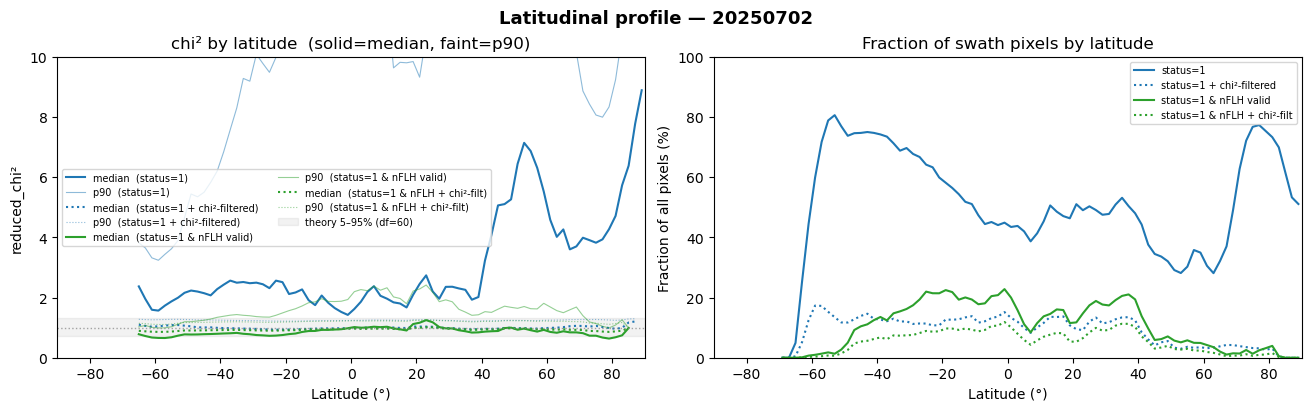

In [29]:
# ── PLOT: median chi2 and convergence rate by latitude band ───────────────────
# Reload lat alongside chi2/stat for the spatial view
lat_all = []
for svd_path in svd_files:
    with nc.Dataset(svd_path, "r") as ds:
        lat_all.append(np.array(ds["latitude"][:]).ravel())
lat = np.concatenate(lat_all)

LAT_BINS    = np.arange(-90, 91, 2)   # 2° bands
lat_centers = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

# chi2 in-band filter reusing CHI2_LO/CHI2_HI from the stats cell (df=60)
chi2_inband = np.isfinite(chi2) & (chi2 >= CHI2_LO) & (chi2 <= CHI2_HI)

populations_lat = [
    ((stat == 1),                            "status=1",                    "C0", "-"),
    ((stat == 1) & chi2_inband,              "status=1 + chi²-filtered",    "C0", ":"),
    ((stat == 1) & nflh_ok,                  "status=1 & nFLH valid",       "C2", "-"),
    ((stat == 1) & nflh_ok & chi2_inband,    "status=1 & nFLH + chi²-filt", "C2", ":"),
]

# Pre-compute per-band stats for each population
results = []
for base_mask, label, color, ls in populations_lat:
    med    = np.full(len(lat_centers), np.nan)
    pct90  = np.full(len(lat_centers), np.nan)
    frac   = np.full(len(lat_centers), np.nan)   # fraction of ALL pixels in band
    for i, (lo, hi) in enumerate(zip(LAT_BINS[:-1], LAT_BINS[1:])):
        in_b = (lat >= lo) & (lat < hi)
        n_total = np.sum(in_b)
        if n_total == 0:
            continue
        frac[i] = np.sum(in_b & base_mask) / n_total * 100
        vals = chi2[in_b & base_mask & np.isfinite(chi2)]
        if len(vals) > 0:
            med[i]   = np.median(vals)
            pct90[i] = np.percentile(vals, 90)
    results.append((med, pct90, frac, label, color, ls))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
fig.suptitle(f"Latitudinal profile — {DATE}", fontsize=13, fontweight="bold")

# ── left: chi² by latitude ────────────────────────────────────────────────────
ax = axes[0]
for med, pct90, frac, label, color, ls in results:
    ax.plot(lat_centers, med,   color=color, linewidth=1.5, linestyle=ls,
            label=f"median  ({label})")
    ax.plot(lat_centers, pct90, color=color, linewidth=0.8, linestyle=ls,
            alpha=0.5, label=f"p90  ({label})")
ax.axhspan(CHI2_LO, CHI2_HI, color="gray", alpha=0.10,
           label=f"theory 5–95% (df={DF_THEORY})")
ax.axhline(1.0, color="gray", linestyle=":",  linewidth=1, alpha=0.7)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("reduced_chi²")
ax.set_xlim(-90, 90)
ax.set_ylim(0, 10)
ax.legend(fontsize=7, ncol=2)
ax.set_title("chi² by latitude  (solid=median, faint=p90)")

# ── right: fraction of all swath pixels by latitude ──────────────────────────
ax = axes[1]
for med, pct90, frac, label, color, ls in results:
    ax.plot(lat_centers, frac, color=color, linewidth=1.5, linestyle=ls, label=label)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Fraction of all pixels (%)")
ax.set_xlim(-90, 90)
ax.set_ylim(0, 100)
ax.legend(fontsize=7)
ax.set_title("Fraction of swath pixels by latitude")

plt.show()

Population sizes:
  (1) all                      : 299,208,348
  (2) status=0|1 + chi²-filter : 32,875,206  (11.0%)
  (3) (2) + l2_flags_reject    : 25,839,142  (8.6%)


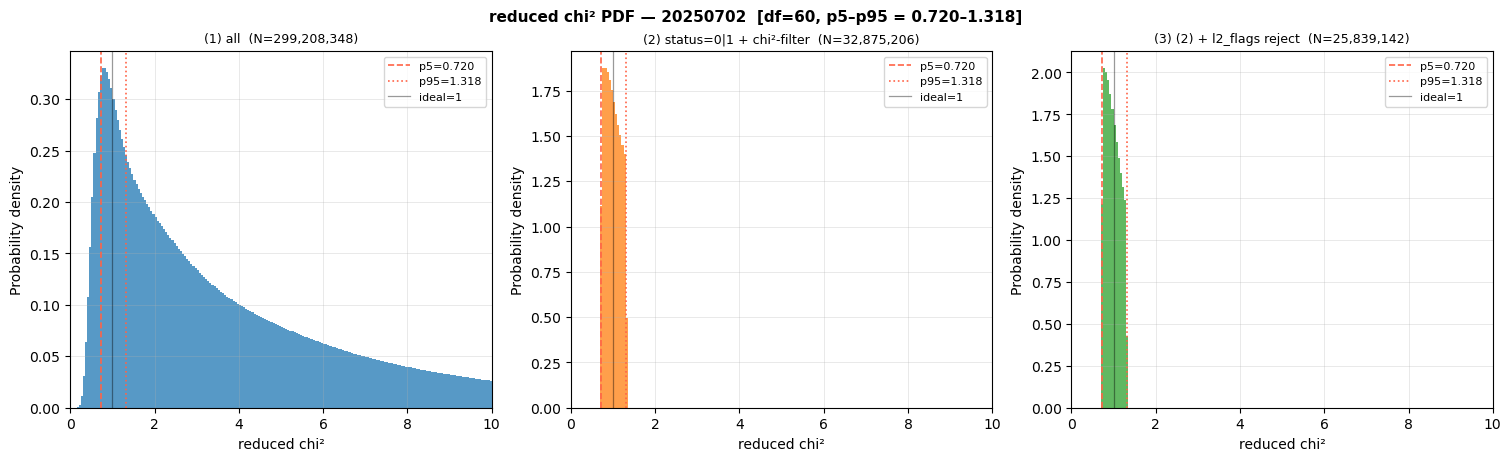

In [30]:
# ── PLOT: reduced_chi2 PDF — 3 filter populations ─────────────────────────────
# (1) all retrievals
# (2) status=0|1  +  chi2 in [CHI2_LO, CHI2_HI]
# (3) (2)  +  l2_flags_reject = LAND | COASTZ | HISOLZEN
# CHI2_LO / CHI2_HI from the theoretical-bounds cell.

# LAND(bit1)=2 | COASTZ(bit6)=64 | HISOLZEN(bit12)=4096
L2FLAGS_REJECT = np.uint32(2 | 64 | 4096)

mask_chi2_stat = (
    ((stat == 0) | (stat == 1)) &
    np.isfinite(chi2) &
    (chi2 >= CHI2_LO) & (chi2 <= CHI2_HI)
)
mask_full = (
    mask_chi2_stat &
    ((flags.astype(np.uint32) & L2FLAGS_REJECT) == 0)
)

finite = np.isfinite(chi2)
pop1 = chi2[finite]
pop2 = chi2[mask_chi2_stat]
pop3 = chi2[mask_full]

print(f"Population sizes:")
print(f"  (1) all                      : {len(pop1):>10,}")
print(f"  (2) status=0|1 + chi²-filter : {len(pop2):>10,}  ({100*len(pop2)/max(len(pop1),1):.1f}%)")
print(f"  (3) (2) + l2_flags_reject    : {len(pop3):>10,}  ({100*len(pop3)/max(len(pop1),1):.1f}%)")

bins = np.linspace(*CHI2_XLIM, CHI2_NBINS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
fig.suptitle(
    f"reduced chi² PDF — {DATE}  "
    f"[df={DF_THEORY}, p5–p95 = {CHI2_LO:.3f}–{CHI2_HI:.3f}]",
    fontsize=11, fontweight="bold",
)

plot_data = [
    (pop1, "C0", f"(1) all  (N={len(pop1):,})"),
    (pop2, "C1", f"(2) status=0|1 + chi²-filter  (N={len(pop2):,})"),
    (pop3, "C2", f"(3) (2) + l2_flags reject  (N={len(pop3):,})"),
]

for ax, (vals, color, label) in zip(axes, plot_data):
    ax.hist(vals, bins=bins, density=True, alpha=0.75, color=color)
    ax.axvline(CHI2_LO, color="tomato", lw=1.2, ls="--", label=f"p5={CHI2_LO:.3f}")
    ax.axvline(CHI2_HI, color="tomato", lw=1.2, ls=":",  label=f"p95={CHI2_HI:.3f}")
    ax.axvline(1.0,     color="k",      lw=0.9, ls="-",  alpha=0.4, label="ideal=1")
    ax.set_xlabel("reduced chi²", fontsize=10)
    ax.set_ylabel("Probability density", fontsize=10)
    ax.set_title(label, fontsize=9)
    ax.set_xlim(*CHI2_XLIM)
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

plt.show()


### 2. SNR modelling from L1B radiance

Flow for this section:
1. Build status=1 pixel catalogue with matching L1B files
2. Example radiance spectra (random pixels)
3. Full-scene mean Lt map + spectra for one granule
4. SNR vs mean Lt scatter, with a data-driven noise model

**Noise model:** assume residual RMSE follows read + photon noise
$$\sigma(L_t) = A + B\sqrt{L_t}$$
so the expected SNR curve is
$$\mathrm{SNR}(L_t) = \frac{L_t}{A + B\sqrt{L_t}}.$$


In [31]:
# ── Catalogue status=1 pixels with matching L1B files ─────────────────────────
# Uses L1B_DIR / l1b_idx / LAMBDA_* from the config cell.

print(f"L1B files for {DATE}: {len(l1b_idx)}")

pixel_records = []   # (svd_path, l1b_path, scan0, pix0, rmse_val)

for svd_path in svd_files:
    m   = SVD_RE.match(os.path.basename(svd_path))
    gid = m.group(1)
    l1b_path = match_l1b(gid)
    if l1b_path is None:
        continue

    with nc.Dataset(svd_path, "r") as ds:
        stat_g = np.array(ds["status_code"][:])
        rmse_g = np.array(ds["rmse"][:])
        si     = np.array(ds["source_scan_index"][:])   # 1-based
        pi     = np.array(ds["source_pixel_index"][:])

    rows, cols = np.where(stat_g == 1)
    for r, c in zip(rows, cols):
        pixel_records.append((
            svd_path, l1b_path,
            int(si[r]) - 1,
            int(pi[c]) - 1,
            float(rmse_g[r, c]),
        ))

print(f"status=1 pixels with L1B match: {len(pixel_records):,}")


L1B files for 20250702: 147
status=1 pixels with L1B match: 169,371,968


In [32]:
# ── ONE GRANULE: MEAN RADIANCE MAP + 10 PIXEL SPECTRA ────────────────────────

LAMBDA_MIN_VIS, LAMBDA_MAX_VIS = LAMBDA_MIN, LAMBDA_MAX
N_PIX = 20

# Pick the first SVD granule of the date
first_svd = "/home/zhe2/data/PACE/svd_retrieval_output/interim_20250702T170504_svd_retrieval_full_gpu.nc"
m_g  = SVD_RE.match(os.path.basename(first_svd))
gid  = m_g.group(1)
l1b_path_g = match_l1b(gid)
l2_path_g  = match_l2(gid)
print(f"Granule : {gid}")
print(f"L1B     : {l1b_path_g}")
print(f"L2 AOP  : {l2_path_g}")

# ── SVD variables ─────────────────────────────────────────────────────────────
with nc.Dataset(first_svd, "r") as ds:
    rmse_g = np.array(ds["rmse"][:], dtype=np.float32)          # (scans, pixels)
    sif_g  = np.array(ds["sif_radiance_678nm"][:], dtype=np.float32)
    lat_g  = np.array(ds["latitude"][:], dtype=np.float32)
    lon_g  = np.array(ds["longitude"][:], dtype=np.float32)

# ── L2 AOP nFLH ──────────────────────────────────────────────────────────────
if l2_path_g:
    with nc.Dataset(l2_path_g, "r") as ds:
        nv        = ds["geophysical_data/nflh"]
        nflh_fv_g = float(nv._FillValue) if hasattr(nv, "_FillValue") else None
        nflh_g    = np.ma.filled(nv[:], np.nan).astype(np.float32)
    if nflh_fv_g is not None:
        nflh_g[nflh_g == nflh_fv_g] = np.nan
else:
    nflh_g = np.full(lat_g.shape, np.nan, dtype=np.float32)

# ── L1B: load FULL radiance scene, then close ────────────────────────────────
print("Loading full L1B scene (~1.4 GB, may take 20–30 s) …", flush=True)
with nc.Dataset(l1b_path_g, "r") as ds:
    wl_full = np.array(ds["sensor_band_parameters/red_wavelength"][:])        # (163,)
    F0_full = np.array(ds["sensor_band_parameters/red_solar_irradiance"][:])  # (163,)
    esd     = float(ds.getncattr("earth_sun_distance_correction"))

    sza_raw = np.array(ds["geolocation_data/solar_zenith"][:]).astype(np.float32)
    # netCDF4 auto-applies scale_factor=0.01 on read → values already in degrees
    cos_sza = np.cos(np.deg2rad(sza_raw))                        # (scans, pixels)

    rhot_full = np.array(ds["observation_data/rhot_red"][:], dtype=np.float32)
    # file closed here → all memory now in rhot_full

# Lt_full: (163, scans, pixels)  [W m⁻² sr⁻¹ µm⁻¹]
Lt_full = rhot_full * F0_full[:, None, None] * cos_sza[None, :, :] / (np.pi * esd)
del rhot_full   # free ~1.4 GB

win         = np.where((wl_full >= LAMBDA_MIN_VIS) & (wl_full <= LAMBDA_MAX_VIS))[0]
mean_Lt_map = Lt_full[win].mean(axis=0)   # (scans, pixels)
print("Done.", flush=True)

# ── Sample N_PIX pixels for plotting ─────────────────────────────────────────
random.seed(42)
scans_n, pix_n = lat_g.shape
flat_idx = random.sample(range(scans_n * pix_n), N_PIX)
scan_ch  = [idx // pix_n for idx in flat_idx]
pix_ch   = [idx  % pix_n for idx in flat_idx]

# Spectra and per-pixel scalar metadata for chosen pixels
Lt_ch       = Lt_full[:, scan_ch, pix_ch]        # (163, N_PIX)
mean_Lt_ch  = Lt_ch[win].mean(axis=0).ravel()    # (N_PIX,)
sza_ch      = sza_raw[scan_ch, pix_ch].ravel()   # (N_PIX,)


Granule : 20250702T170504
L1B     : /home/zhe2/data/PACE/L1B_V3/PACE_OCI.20250702T170504.L1B.V3.nc
L2 AOP  : /home/zhe2/data/PACE/L2_AOP_V3.1/PACE_OCI.20250702T170504.L2.OC_AOP.V3_1.nc
Loading full L1B scene (~1.4 GB, may take 20–30 s) …
Done.


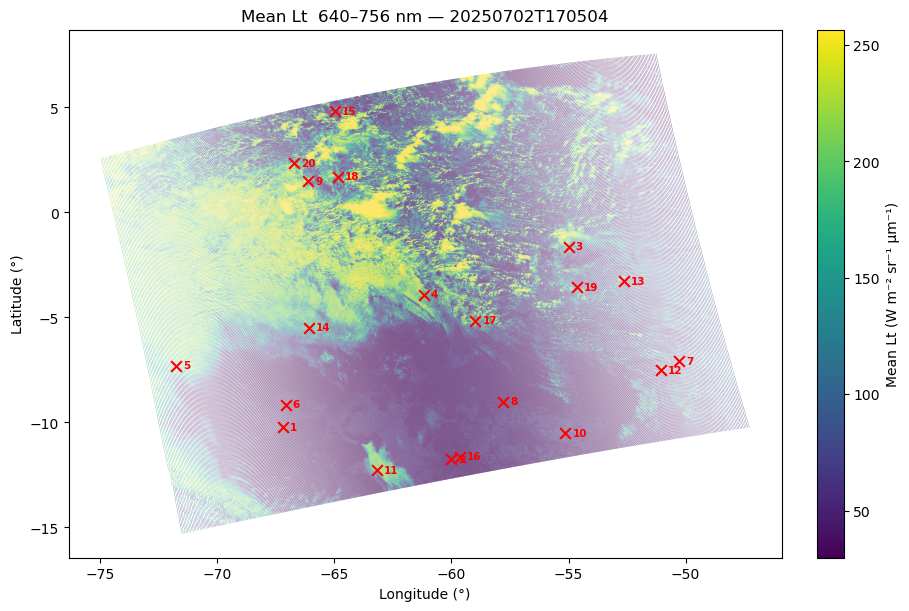

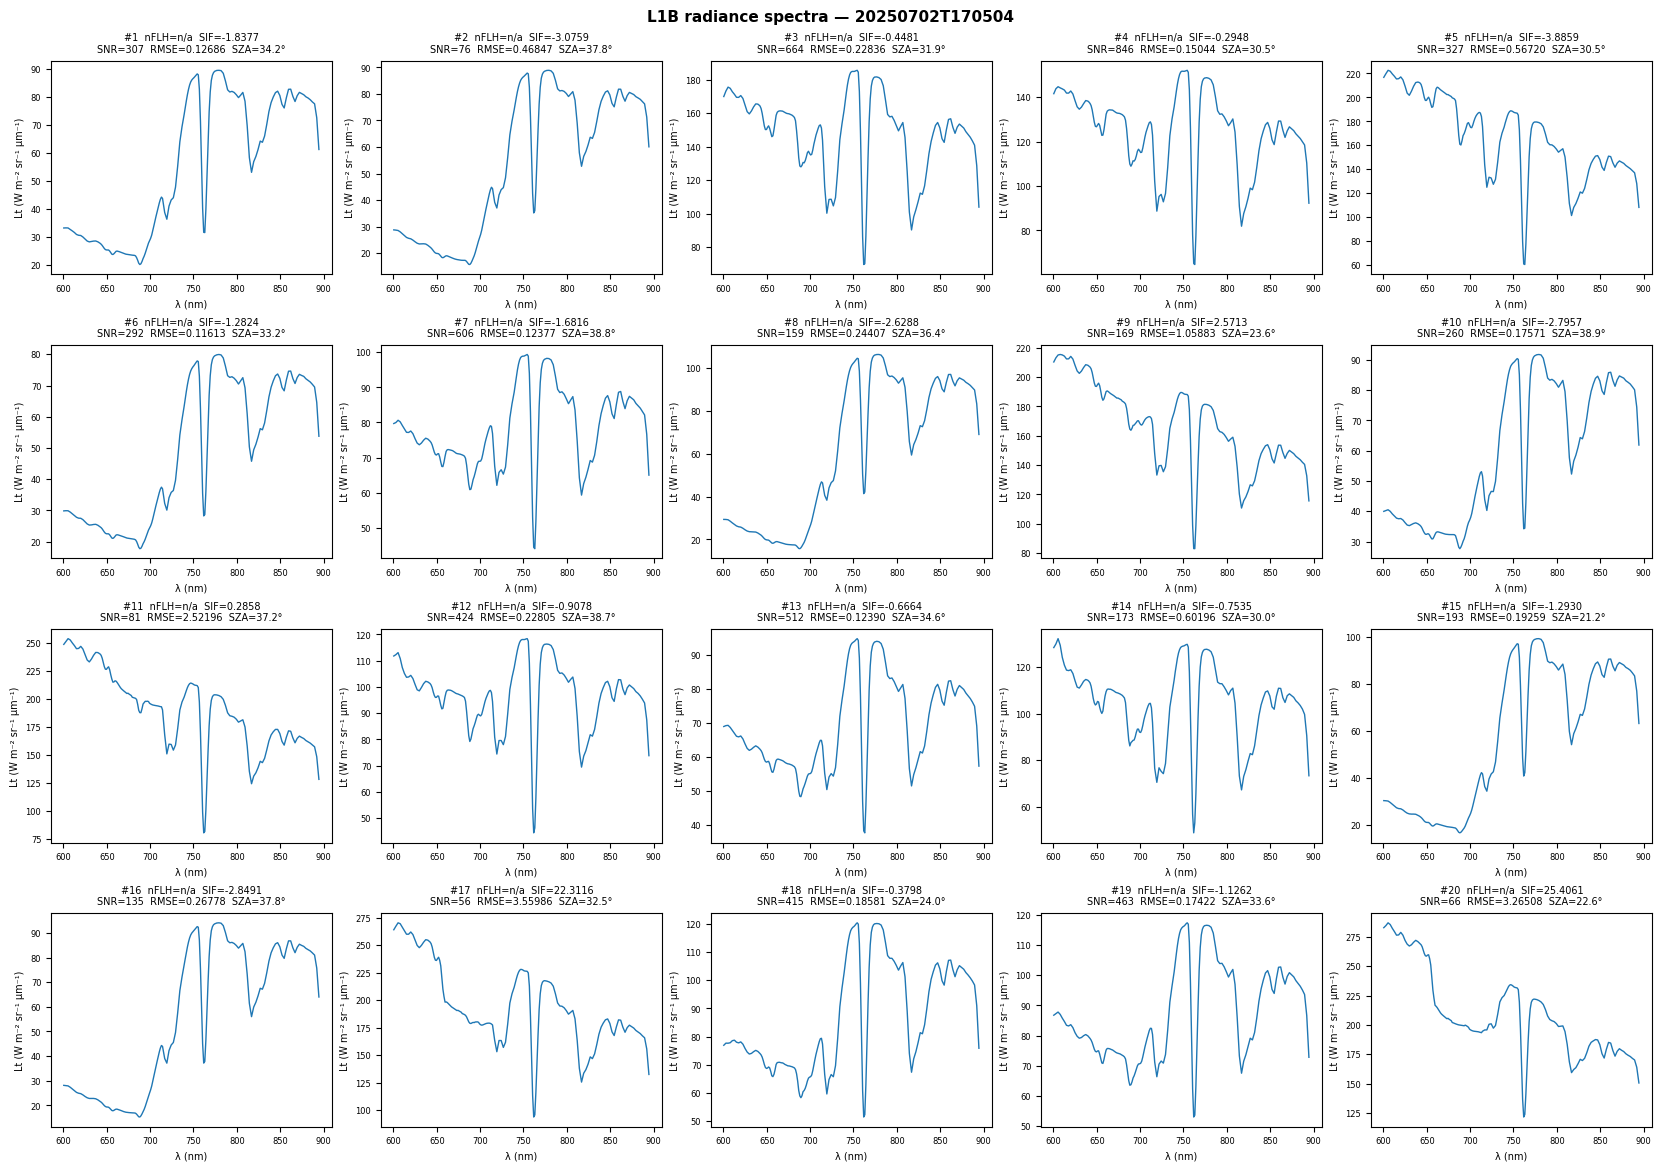

In [33]:
# ── FIGURE 1: Mean radiance map + overlay ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
vlo, vhi = np.nanpercentile(mean_Lt_map, [2, 98])
sc = ax.scatter(lon_g.ravel(), lat_g.ravel(),
                c=mean_Lt_map.ravel(), s=0.04,
                cmap="viridis", vmin=vlo, vmax=vhi, linewidths=0)
plt.colorbar(sc, ax=ax, label="Mean Lt (W m⁻² sr⁻¹ µm⁻¹)")
xs = [lon_g[s, p] for s, p in zip(scan_ch, pix_ch)]
ys = [lat_g[s, p] for s, p in zip(scan_ch, pix_ch)]
ax.scatter(xs, ys, c="red", s=60, marker="x", linewidths=1.5, zorder=5)
for k, (x, y) in enumerate(zip(xs, ys)):
    ax.text(x + 0.3, y, str(k + 1), color="red", fontsize=7.5, va="center", fontweight="bold")
ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
ax.set_title(f"Mean Lt  {LAMBDA_MIN_VIS:.0f}–{LAMBDA_MAX_VIS:.0f} nm — {gid}")
plt.show()

# ── FIGURE 2: Radiance spectra of chosen pixels ───────────────────────────────
ncols, nrows = 5, (N_PIX + 4) // 5
fig2, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.3, nrows * 2.9),
                           constrained_layout=True)
fig2.suptitle(f"L1B radiance spectra — {gid}", fontsize=11, fontweight="bold")

for k, (s, p) in enumerate(zip(scan_ch, pix_ch)):
    ax       = axes.ravel()[k]
    rmse_val = float(rmse_g[s, p])
    sif_val  = float(sif_g[s, p])
    nflh_val = float(nflh_g[s, p])
    sza_val  = float(sza_ch[k])
    sig_val  = float(mean_Lt_ch[k])
    snr_val  = sig_val / rmse_val if (np.isfinite(rmse_val) and rmse_val > 0) else np.nan

    ax.plot(wl_full, Lt_ch[:, k], linewidth=1.0, color="C0")
    nflh_str = f"{nflh_val:.3f}" if np.isfinite(nflh_val) else "n/a"
    ax.set_title(
        f"#{k+1}  nFLH={nflh_str}  SIF={sif_val:.4f}\n"
        f"SNR={snr_val:.0f}  RMSE={rmse_val:.5f}  SZA={sza_val:.1f}°",
        fontsize=7
    )
    ax.set_xlabel("λ (nm)", fontsize=7)
    ax.set_ylabel("Lt (W m⁻² sr⁻¹ µm⁻¹)", fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes.ravel()[N_PIX:]:
    ax.set_visible(False)
plt.show()


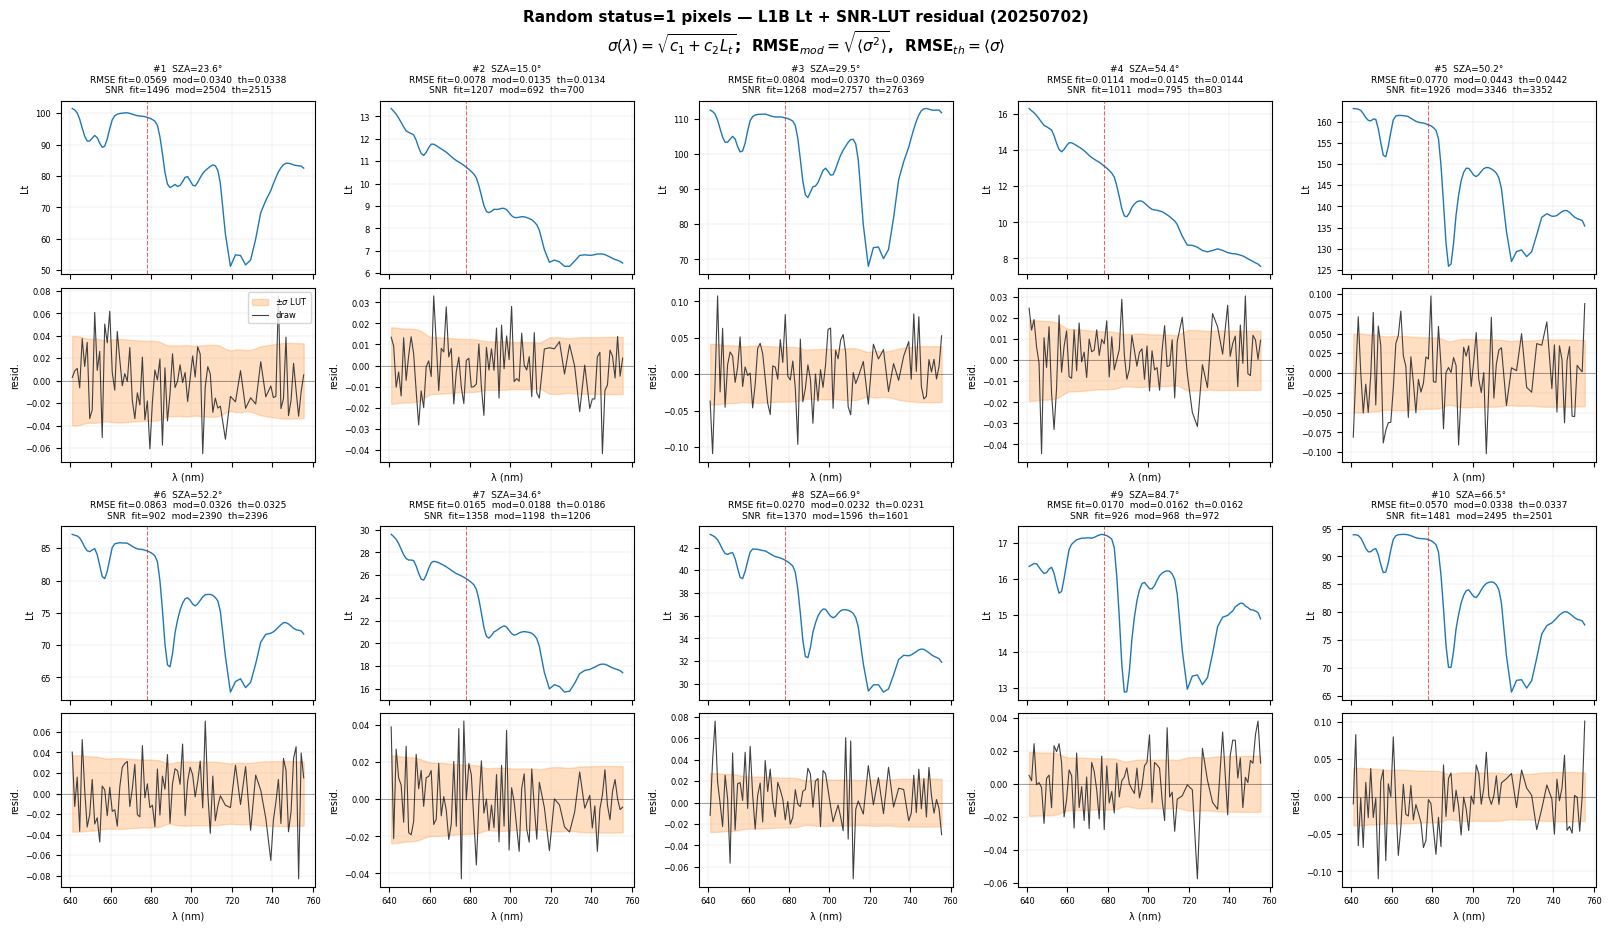

  #    RMSE_fit    RMSE_mod     RMSE_th   SNR_fit   SNR_mod    SNR_th
  1     0.05689     0.03398     0.03384    1495.8    2504.2    2514.5
  2     0.00777     0.01354     0.01339    1207.0     692.4     700.4
  3     0.08041     0.03697     0.03688    1267.7    2756.8    2763.5
  4     0.01143     0.01454     0.01439    1011.3     794.6     802.8
  5     0.07695     0.04428     0.04421    1925.7    3346.2    3352.2
  6     0.08631     0.03255     0.03248     901.6    2390.3    2395.6
  7     0.01654     0.01875     0.01863    1358.1    1198.2    1205.8
  8     0.02699     0.02317     0.02309    1370.1    1595.8    1601.1
  9     0.01696     0.01622     0.01615     925.6     967.7     972.0
 10     0.05699     0.03382     0.03375    1480.7    2494.9    2500.6


In [34]:
# ── Random status=1 spectra + SNR-LUT residual / modelled & theoretical RMSE ──
# Noise from official LUT:  σ(λ) = sqrt(c1(λ) + c2(λ)·Lt(λ))
#   residual draw     r(λ) ~ N(0, σ(λ))
#   RMSE_modelled     = sqrt(mean(σ²))          # RMS of per-band noise
#   RMSE_theoretical  = mean(σ)                 # direct mean of per-band σ
# Annotates SVD retrieval RMSE_fit alongside both.

SNR_LUT_FILE = "/home/zhe2/course_doc/PACE_OCI_L1B_LUT_baseline_SNR_1.1.txt"
N_EXAMPLES = 10
random.seed(42)

# ── load Red SNR LUT ──────────────────────────────────────────────────────────
def load_red_snr_lut(path=SNR_LUT_FILE):
    with open(path) as f:
        lines = f.readlines()
    hdr_end = next(i for i, ln in enumerate(lines) if ln.strip() == "/end_header")
    wl_lut, c1_lut, c2_lut = [], [], []
    for ln in lines[hdr_end + 1:]:
        parts = ln.split()
        if len(parts) < 5 or parts[0] != "Red":
            continue
        wl_lut.append(float(parts[1]))
        c1_lut.append(float(parts[3]))
        c2_lut.append(float(parts[4]))
    return (np.asarray(wl_lut), np.asarray(c1_lut), np.asarray(c2_lut))

wl_lut, c1_lut, c2_lut = load_red_snr_lut()

def lut_sigma(Lt, c1_, c2_):
    """Expected noise std from Meister LUT: σ = sqrt(c1 + c2·L)."""
    return np.sqrt(np.maximum(c1_ + c2_ * Lt, 0.0))

def interp_lut_coeffs(wl_pix):
    """Nearest-neighbour map of Red LUT c1/c2 onto pixel wavelengths."""
    j = np.argmin(np.abs(wl_lut[:, None] - wl_pix[None, :]), axis=0)
    return c1_lut[j], c2_lut[j]

# ── pick pixels (requires pixel_records from the catalogue cell) ──────────────
chosen = random.sample(pixel_records, min(N_EXAMPLES, len(pixel_records)))

by_l1b = defaultdict(list)
for rec in chosen:
    by_l1b[rec[1]].append(rec)

spectra = {}

for l1b_path, recs in by_l1b.items():
    ds = nc.Dataset(l1b_path, "r")
    try:
        wl_all = np.array(ds["sensor_band_parameters/red_wavelength"][:], dtype=float)
        F0_all = np.array(ds["sensor_band_parameters/red_solar_irradiance"][:], dtype=float)
        win    = np.where((wl_all >= LAMBDA_MIN) & (wl_all <= LAMBDA_MAX))[0]
        wl     = wl_all[win]
        F0     = F0_all[win]
        esd    = float(ds.getncattr("earth_sun_distance_correction"))
        c1_w, c2_w = interp_lut_coeffs(wl)

        for (svd_path, _, scan0, pix0, rmse_fit) in recs:
            rhot = np.array(ds["observation_data/rhot_red"][win, scan0, pix0],
                            dtype=np.float64)
            sza_deg = float(ds["geolocation_data/solar_zenith"][scan0, pix0])
            cos_sza = np.cos(np.deg2rad(sza_deg))
            Lt = rhot * F0 * cos_sza / (np.pi * esd)

            sigma = lut_sigma(Lt, c1_w, c2_w)
            residual = np.random.default_rng(
                abs(hash((scan0, pix0))) % (2**32)
            ).normal(0.0, sigma)

            # modelled: RMS of LUT σ(λ); theoretical: direct mean of band σ
            rmse_mod = float(np.sqrt(np.mean(sigma ** 2)))
            rmse_th  = float(np.mean(sigma))
            mean_sig = float(np.mean(Lt))
            snr_fit  = mean_sig / rmse_fit if rmse_fit > 0 else np.nan
            snr_mod  = mean_sig / rmse_mod if rmse_mod > 0 else np.nan
            snr_th   = mean_sig / rmse_th  if rmse_th  > 0 else np.nan

            spectra[(svd_path, scan0, pix0)] = dict(
                wl=wl, Lt=Lt, residual=residual, sigma=sigma,
                sza=sza_deg, mean_sig=mean_sig,
                rmse_fit=float(rmse_fit), rmse_mod=rmse_mod, rmse_th=rmse_th,
                snr_fit=snr_fit, snr_mod=snr_mod, snr_th=snr_th,
            )
    finally:
        ds.close()

# ── plot: radiance (top) + residual (bottom) for each example ─────────────────
ncols = 5
nrows = (N_EXAMPLES + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows * 2, ncols,
    figsize=(ncols * 3.2, nrows * 4.6),
    constrained_layout=True,
    sharex="col",
)
fig.suptitle(
    f"Random status=1 pixels — L1B Lt + SNR-LUT residual ({DATE})\n"
    r"$\sigma(\lambda)=\sqrt{c_1+c_2 L_t}$;  "
    r"RMSE$_{mod}=\sqrt{\langle\sigma^2\rangle}$,  "
    r"RMSE$_{th}=\langle\sigma\rangle$",
    fontsize=11, fontweight="bold",
)

if axes.ndim == 1:
    axes = axes.reshape(2, -1)

for k, rec in enumerate(chosen):
    col = k % ncols
    row = k // ncols
    ax_lt  = axes[row * 2,     col]
    ax_res = axes[row * 2 + 1, col]

    key = (rec[0], rec[2], rec[3])
    if key not in spectra:
        ax_lt.set_visible(False)
        ax_res.set_visible(False)
        continue

    d = spectra[key]
    wl, Lt, resid, sig = d["wl"], d["Lt"], d["residual"], d["sigma"]

    ax_lt.plot(wl, Lt, lw=1.0, color="C0")
    ax_lt.axvline(678, color="C3", ls="--", lw=0.8, alpha=0.7)
    ax_lt.set_title(
        f"#{k+1}  SZA={d['sza']:.1f}°\n"
        f"RMSE fit={d['rmse_fit']:.4f}  mod={d['rmse_mod']:.4f}  th={d['rmse_th']:.4f}\n"
        f"SNR  fit={d['snr_fit']:.0f}  mod={d['snr_mod']:.0f}  th={d['snr_th']:.0f}",
        fontsize=6.5,
    )
    ax_lt.set_ylabel("Lt", fontsize=7)
    ax_lt.tick_params(labelsize=6)
    ax_lt.grid(True, lw=0.3, alpha=0.4)

    ax_res.fill_between(wl, -sig, sig, color="C1", alpha=0.25, label=r"$\pm\sigma$ LUT")
    ax_res.plot(wl, resid, lw=0.8, color="0.25", label="draw")
    ax_res.axhline(0, color="k", lw=0.5, alpha=0.5)
    ax_res.set_xlabel("λ (nm)", fontsize=7)
    ax_res.set_ylabel("resid.", fontsize=7)
    ax_res.tick_params(labelsize=6)
    ax_res.grid(True, lw=0.3, alpha=0.4)
    if k == 0:
        ax_res.legend(fontsize=6, loc="upper right")

for k in range(len(chosen), nrows * ncols):
    col = k % ncols
    row = k // ncols
    axes[row * 2,     col].set_visible(False)
    axes[row * 2 + 1, col].set_visible(False)

plt.show()

print(f"{'#':>3}  {'RMSE_fit':>10}  {'RMSE_mod':>10}  {'RMSE_th':>10}  "
      f"{'SNR_fit':>8}  {'SNR_mod':>8}  {'SNR_th':>8}")
for k, rec in enumerate(chosen):
    d = spectra.get((rec[0], rec[2], rec[3]))
    if d is None:
        continue
    print(f"{k+1:3d}  {d['rmse_fit']:10.5f}  {d['rmse_mod']:10.5f}  {d['rmse_th']:10.5f}  "
          f"{d['snr_fit']:8.1f}  {d['snr_mod']:8.1f}  {d['snr_th']:8.1f}")


Theoretical SNR uses 83 instrument bands in [640, 756] nm (LUT λ matched nearest-neighbour)
status=0  (N=509, 20 ≤ Lt < 70):
  σ(Lt) = 0.139228  +  0.00891536 · √Lt
  R² (RMSE) = 0.0017
status=1  (N=2,296, 20 ≤ Lt < 70):
  σ(Lt) = 0.168735  +  0.0055699 · √Lt
  R² (RMSE) = 0.0019
theoretical LUT  (N=5,052, 20 ≤ Lt < 70):
  σ(Lt) = -3.73035e-06  +  0.00365579 · √Lt
  R² (RMSE) = 0.9850
  note: A < 0 (unphysical read-noise intercept); empirical curve only


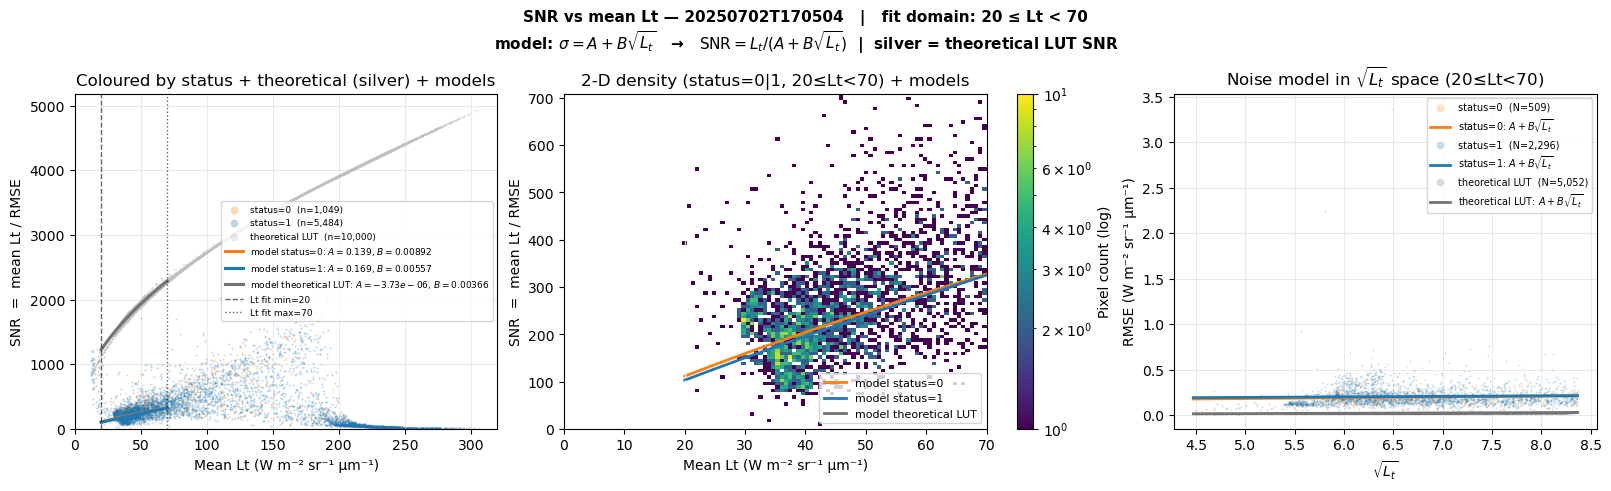


status=0 in sample (20≤Lt<70): 509
  SNR  median=248.8  p10=143.7  p90=405.9
  At Lt=20:  model SNR = 111.7
  At Lt=30:  model SNR = 159.5
  At Lt=50:  model SNR = 247.2
status=1 in sample (20≤Lt<70): 2,296
  SNR  median=238.4  p10=132.0  p90=410.3
  At Lt=20:  model SNR = 103.3
  At Lt=30:  model SNR = 150.6
  At Lt=50:  model SNR = 240.2
theoretical LUT model:
  At Lt=20:  fit SNR = 1223.6  |  flat-spectrum LUT SNR = 1125.4
  At Lt=30:  fit SNR = 1498.5  |  flat-spectrum LUT SNR = 1423.8
  At Lt=50:  fit SNR = 1934.5  |  flat-spectrum LUT SNR = 1890.2


In [35]:
# ── SNR vs mean Lt + data-driven noise model ──────────────────────────────────
# Reuses mean_Lt_map, rmse_g, lat_g, first_svd from the granule-loading cell.
#
# Noise model:  σ(Lt) = A + B √Lt
#               SNR(Lt) = Lt / (A + B √Lt)
# Fit A, B separately for status=0 and status=1, using LT_FIT_MIN ≤ Lt < LT_FIT_MAX.
# Also compute theoretical SNR from the PACE Red SNR LUT (Meister et al.):
#   For each pixel, use the original Lt(λ) spectrum (not mean Lt):
#   σ_i = sqrt(c1_i + c2_i · Lt_i)  for each retrieval-window band
#   RMSE_th = ⟨σ_i⟩_λ ,  SNR_th = ⟨Lt⟩_λ / RMSE_th
# Plot SNR_th as silver scatter on panel (a) and fit an additional A+B√Lt model.

N_SCATTER = 10_000
LT_FIT_MIN = 20.0   # W m⁻² sr⁻¹ µm⁻¹ — exclude very dark pixels from the fit
LT_FIT_MAX = 70.0   # W m⁻² sr⁻¹ µm⁻¹ — exclude bright pixels from the fit
SNR_LUT_FILE = "/home/zhe2/course_doc/PACE_OCI_L1B_LUT_baseline_SNR_1.1.txt"
random.seed(7)

scans_n, pix_n = lat_g.shape
samp_idx = random.sample(range(scans_n * pix_n), min(N_SCATTER, scans_n * pix_n))
s_idx = np.array([i // pix_n for i in samp_idx])
p_idx = np.array([i  % pix_n for i in samp_idx])

mean_Lt_s = mean_Lt_map[s_idx, p_idx].astype(float)
rmse_s    = rmse_g[s_idx, p_idx].astype(float)

try:
    stat_s = stat_g[s_idx, p_idx]
except NameError:
    with nc.Dataset(first_svd, "r") as ds:
        stat_g = np.array(ds["status_code"][:])
    stat_s = stat_g[s_idx, p_idx]

with np.errstate(divide="ignore", invalid="ignore"):
    snr_s = np.where(rmse_s > 0, mean_Lt_s / rmse_s, np.nan)

# ── theoretical SNR from Red LUT (per-band σ on each pixel's Lt spectrum) ─────
with open(SNR_LUT_FILE) as f:
    _lines = f.readlines()
_hdr = next(i for i, ln in enumerate(_lines) if ln.strip() == "/end_header")
_wl, _c1, _c2 = [], [], []
for ln in _lines[_hdr + 1:]:
    parts = ln.split()
    if len(parts) < 5 or parts[0] != "Red":
        continue
    _wl.append(float(parts[1])); _c1.append(float(parts[3])); _c2.append(float(parts[4]))
_wl, _c1, _c2 = np.asarray(_wl), np.asarray(_c1), np.asarray(_c2)

# Match LUT coeffs onto the instrument wavelengths in the retrieval window
wl_win = np.asarray(wl_full[win], dtype=float)
lut_idx = np.array([int(np.argmin(np.abs(_wl - w))) for w in wl_win])
c1_w, c2_w = _c1[lut_idx], _c2[lut_idx]
print(f"Theoretical SNR uses {c1_w.size} instrument bands in "
      f"[{LAMBDA_MIN:.0f}, {LAMBDA_MAX:.0f}] nm "
      f"(LUT λ matched nearest-neighbour)")

# Original Lt spectra for sampled pixels: (n_bands, N)
Lt_spec_s = Lt_full[win][:, s_idx, p_idx].astype(float)

def theoretical_snr(Lt_spec):
    """SNR_th from original per-band Lt spectra (not mean Lt).

    Lt_spec : (n_bands,) or (n_bands, n_pix)
    σ_i = sqrt(c1_i + c2_i · Lt_i)
    RMSE_th = ⟨σ⟩_λ ,  SNR_th = ⟨Lt⟩_λ / RMSE_th
    """
    Lt_spec = np.asarray(Lt_spec, dtype=float)
    if Lt_spec.ndim == 1:
        Lt_spec = Lt_spec[:, None]
    sig = np.sqrt(np.maximum(c1_w[:, None] + c2_w[:, None] * Lt_spec, 0.0))
    rmse_th = np.nanmean(sig, axis=0)
    mean_Lt = np.nanmean(Lt_spec, axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        snr_th = np.where(rmse_th > 0, mean_Lt / rmse_th, np.nan)
    return snr_th, rmse_th

snr_th_s, rmse_th_s = theoretical_snr(Lt_spec_s)

# ── Fit σ = A + B √Lt for status=0, status=1, and theoretical ─────────────────
def fit_noise_model(Lt, rmse, label):
    """Least-squares fit RMSE ≈ A + B √Lt."""
    mask = (
        np.isfinite(Lt) & (Lt >= LT_FIT_MIN) & (Lt < LT_FIT_MAX) &
        np.isfinite(rmse) & (rmse > 0)
    )
    Lt_f, rmse_f = Lt[mask], rmse[mask]
    if len(Lt_f) < 10:
        return None
    sqrt_Lt = np.sqrt(Lt_f)
    G = np.column_stack([np.ones_like(sqrt_Lt), sqrt_Lt])
    coef, *_ = np.linalg.lstsq(G, rmse_f, rcond=None)
    A, B = float(coef[0]), float(coef[1])
    pred = A + B * sqrt_Lt
    ss_res = float(np.sum((rmse_f - pred) ** 2))
    ss_tot = float(np.sum((rmse_f - rmse_f.mean()) ** 2))
    r2 = 1.0 - ss_res / max(ss_tot, 1e-30)
    return dict(A=A, B=B, r2=r2, N=int(mask.sum()),
                Lt=Lt_f, rmse=rmse_f, sqrt_Lt=sqrt_Lt, label=label)

fits = {}
for sc in (0, 1):
    m = (stat_s == sc)
    fits[sc] = fit_noise_model(mean_Lt_s[m], rmse_s[m], f"status={sc}")

# theoretical fit: use all selected pixels with valid Lt (status-agnostic LUT)
fits["th"] = fit_noise_model(mean_Lt_s, rmse_th_s, "theoretical LUT")

for key in (0, 1, "th"):
    f = fits[key]
    if f is None:
        print(f"{key}: too few points for fit "
              f"({LT_FIT_MIN:g} ≤ Lt < {LT_FIT_MAX:g})")
        continue
    print(f"{f['label']}  (N={f['N']:,}, {LT_FIT_MIN:g} ≤ Lt < {LT_FIT_MAX:g}):")
    print(f"  σ(Lt) = {f['A']:.6g}  +  {f['B']:.6g} · √Lt")
    print(f"  R² (RMSE) = {f['r2']:.4f}")
    if f['A'] < 0:
        print("  note: A < 0 (unphysical read-noise intercept); empirical curve only")

# Smooth curves over the fit radiance range
Lt_curve = np.linspace(LT_FIT_MIN, LT_FIT_MAX, 300)
FIT_STYLE = {
    0:    dict(color="C1",     label="status=0"),
    1:    dict(color="C0",     label="status=1"),
    "th": dict(color="0.45",   label="theoretical LUT"),
}

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
fig.suptitle(
    f"SNR vs mean Lt — {gid}   |   fit domain: {LT_FIT_MIN:g} ≤ Lt < {LT_FIT_MAX:g}\n"
    r"model: $\sigma = A + B\sqrt{L_t}$   →   "
    r"$\mathrm{SNR} = L_t / (A + B\sqrt{L_t})$"
    r"  |  silver = theoretical LUT SNR",
    fontsize=11, fontweight="bold",
)

# (1) scatter by status + silver theoretical + model curves
ax = axes[0]
for sc in (0, 1):
    style = FIT_STYLE[sc]
    ok = (stat_s == sc) & np.isfinite(snr_s) & np.isfinite(mean_Lt_s)
    ax.scatter(mean_Lt_s[ok], snr_s[ok],
               s=2, alpha=0.30, color=style["color"], linewidths=0,
               label=f"{style['label']}  (n={ok.sum():,})")

# theoretical SNR scatter (silver)
ok_th = np.isfinite(snr_th_s) & np.isfinite(mean_Lt_s) & (mean_Lt_s > 0)
ax.scatter(mean_Lt_s[ok_th], snr_th_s[ok_th],
           s=2, alpha=0.35, color="silver", linewidths=0,
           label=f"theoretical LUT  (n={ok_th.sum():,})", zorder=2)

for key in (0, 1, "th"):
    f = fits[key]
    if f is None:
        continue
    style = FIT_STYLE[key]
    snr_c = Lt_curve / (f['A'] + f['B'] * np.sqrt(Lt_curve))
    ls = "-" if key == "th" else "-"
    ax.plot(Lt_curve, snr_c, color=style["color"], lw=2.2, ls=ls,
            label=fr"model {style['label']}: $A={f['A']:.3g}$, $B={f['B']:.3g}$")

ax.axvline(LT_FIT_MIN, color="k", ls="--", lw=1.0, alpha=0.6, label=f"Lt fit min={LT_FIT_MIN:g}")
ax.axvline(LT_FIT_MAX, color="k", ls=":",  lw=1.0, alpha=0.6, label=f"Lt fit max={LT_FIT_MAX:g}")
ax.set_xlabel("Mean Lt (W m⁻² sr⁻¹ µm⁻¹)")
ax.set_ylabel("SNR  =  mean Lt / RMSE")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(fontsize=6.5, markerscale=4)
ax.set_title("Coloured by status + theoretical (silver) + models")
ax.grid(True, lw=0.4, alpha=0.5)

# (2) 2-D density (status=0|1 within fit window) + all model curves
ax = axes[1]
ok = (
    ((stat_s == 0) | (stat_s == 1)) &
    np.isfinite(snr_s) & np.isfinite(mean_Lt_s) &
    (mean_Lt_s >= LT_FIT_MIN) & (mean_Lt_s < LT_FIT_MAX) & (snr_s > 0)
)
xmax = 70.0
ymax = float(np.nanpercentile(snr_s[ok], 99)) if ok.any() else 1.0
_, _, _, img = ax.hist2d(
    mean_Lt_s[ok], snr_s[ok],
    bins=100, range=[[0, xmax], [0, ymax]],
    cmap="viridis", norm=LogNorm(),
)
plt.colorbar(img, ax=ax, label="Pixel count (log)")
for key in (0, 1, "th"):
    f = fits[key]
    if f is None:
        continue
    style = FIT_STYLE[key]
    snr_c = Lt_curve / (f['A'] + f['B'] * np.sqrt(Lt_curve))
    ax.plot(Lt_curve, snr_c, color=style["color"], lw=2.0, label=f"model {style['label']}")
ax.axvline(LT_FIT_MIN, color="w", ls="--", lw=1.0, alpha=0.8)
ax.axvline(LT_FIT_MAX, color="w", ls=":",  lw=1.0, alpha=0.8)
ax.set_xlabel("Mean Lt (W m⁻² sr⁻¹ µm⁻¹)")
ax.set_ylabel("SNR  =  mean Lt / RMSE")
ax.set_title(f"2-D density (status=0|1, {LT_FIT_MIN:g}≤Lt<{LT_FIT_MAX:g}) + models")
ax.legend(fontsize=8, loc="lower right")

# (3) RMSE vs √Lt — linear fit view including theoretical
ax = axes[2]
for key in (0, 1, "th"):
    f = fits[key]
    if f is None:
        continue
    style = FIT_STYLE[key]
    ax.scatter(f['sqrt_Lt'], f['rmse'], s=2, alpha=0.25,
               color=style["color"], linewidths=0,
               label=f"{style['label']}  (N={f['N']:,})")
    rmse_c = f['A'] + f['B'] * np.sqrt(Lt_curve)
    ax.plot(np.sqrt(Lt_curve), rmse_c, color=style["color"], lw=2.0,
            label=fr"{style['label']}: $A+B\sqrt{{L_t}}$")
ax.set_xlabel(r"$\sqrt{L_t}$")
ax.set_ylabel("RMSE (W m⁻² sr⁻¹ µm⁻¹)")
ax.set_title(fr"Noise model in $\sqrt{{L_t}}$ space ({LT_FIT_MIN:g}≤Lt<{LT_FIT_MAX:g})")
ax.legend(fontsize=7, markerscale=4)
ax.grid(True, lw=0.4, alpha=0.5)

plt.show()

# quick stats + model SNR at reference Lt
print()
for sc in (0, 1):
    s_mask = (
        (stat_s == sc) & np.isfinite(snr_s) &
        (mean_Lt_s >= LT_FIT_MIN) & (mean_Lt_s < LT_FIT_MAX)
    )
    print(f"status={sc} in sample ({LT_FIT_MIN:g}≤Lt<{LT_FIT_MAX:g}): {s_mask.sum():,}")
    if s_mask.any():
        print(f"  SNR  median={np.nanmedian(snr_s[s_mask]):.1f}  "
              f"p10={np.nanpercentile(snr_s[s_mask],10):.1f}  "
              f"p90={np.nanpercentile(snr_s[s_mask],90):.1f}")
    f = fits[sc]
    if f is None:
        continue
    for Lt_ref in (20.0, 30.0, 50.0):
        snr_m = Lt_ref / (f['A'] + f['B'] * np.sqrt(Lt_ref))
        print(f"  At Lt={Lt_ref:.0f}:  model SNR = {snr_m:.1f}")

fth = fits.get("th")
if fth is not None:
    print(f"theoretical LUT model:")
    for Lt_ref in (20.0, 30.0, 50.0):
        snr_m = Lt_ref / (fth['A'] + fth['B'] * np.sqrt(Lt_ref))
        # flat spectrum at Lt_ref (diagnostic only; scatter uses real Lt(λ))
        snr_direct, _ = theoretical_snr(np.full(c1_w.size, Lt_ref))
        print(f"  At Lt={Lt_ref:.0f}:  fit SNR = {snr_m:.1f}  "
              f"|  flat-spectrum LUT SNR = {float(snr_direct[0]):.1f}")


Loaded SNR LUT: /home/zhe2/course_doc/PACE_OCI_L1B_LUT_baseline_SNR_1.1.txt
  Red bands: 163  |  wavelength range 600.5–894.6 nm
  target 650 nm → Red λ=649.67 nm  c1=0.0001379  c2=1.384e-05
  target 678 nm → Red λ=678.21 nm  c1=2.478e-05  c2=1.26e-05
  target 700 nm → Red λ=700.61 nm  c1=1.949e-05  c2=1.234e-05
  target 740 nm → Red λ=740.53 nm  c1=9.699e-05  c2=1.239e-05


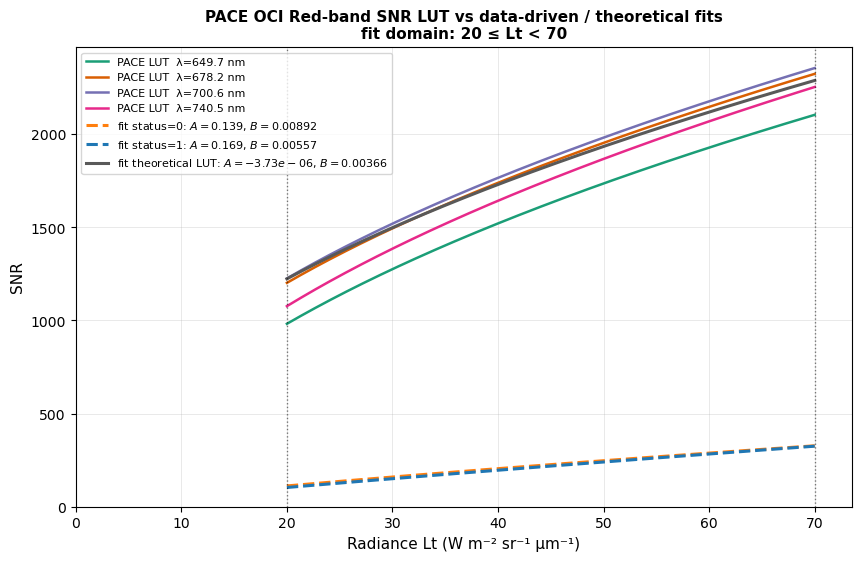


SNR comparison at selected Lt:
      Lt  LUT@650  LUT@678  LUT@701  LUT@741  fit_s0  fit_s1  fit_th
      20     982.2    1202.0    1225.7    1076.9     111.7     103.3    1223.6
      30    1275.7    1494.7    1519.9    1385.5     159.5     150.6    1498.5
      40    1521.2    1739.3    1766.1    1642.9     204.5     196.1    1730.3
      50    1735.7    1953.8    1982.1    1867.6     247.2     240.2    1934.5


In [36]:
# ── Overlay official PACE OCI L1B SNR LUT (red bands) on fitted models ────────
# LUT formula (Meister et al. 2024):  SNR(L) = L / sqrt(c1 + c2·L)
# Requires `fits`, `LT_FIT_MIN`, `LT_FIT_MAX` from the A+B√Lt fit cell above.
# Also overlays the additional theoretical-LUT A+B√Lt fit (`fits["th"]`).

SNR_LUT_FILE = "/home/zhe2/course_doc/PACE_OCI_L1B_LUT_baseline_SNR_1.1.txt"

# Representative red bands near the SIF window (nm)
TARGET_WL_NM = [650.0, 678.0, 700.0, 740.0]

# ── parse LUT (skip SeaBASS-style header) ─────────────────────────────────────
with open(SNR_LUT_FILE) as f:
    lines = f.readlines()
hdr_end = next(i for i, ln in enumerate(lines) if ln.strip() == "/end_header")

fpa, wl, c1, c2 = [], [], [], []
for ln in lines[hdr_end + 1:]:
    parts = ln.split()
    if len(parts) < 5:
        continue
    fpa.append(parts[0])
    wl.append(float(parts[1]))
    c1.append(float(parts[3]))
    c2.append(float(parts[4]))

fpa = np.array(fpa)
wl  = np.array(wl)
c1  = np.array(c1)
c2  = np.array(c2)

red = fpa == "Red"
print(f"Loaded SNR LUT: {SNR_LUT_FILE}")
print(f"  Red bands: {red.sum()}  |  wavelength range "
      f"{wl[red].min():.1f}–{wl[red].max():.1f} nm")

# Pick nearest Red band to each target wavelength
chosen = []
for tw in TARGET_WL_NM:
    j = int(np.argmin(np.abs(wl[red] - tw)))
    idx = np.where(red)[0][j]
    chosen.append(idx)
    print(f"  target {tw:.0f} nm → Red λ={wl[idx]:.2f} nm  "
          f"c1={c1[idx]:.4g}  c2={c2[idx]:.4g}")

# ── SNR curves ────────────────────────────────────────────────────────────────
Lt_plot = np.linspace(max(LT_FIT_MIN, 1.0), LT_FIT_MAX, 300)

def lut_snr(L, c1_, c2_):
    return L / np.sqrt(c1_ + c2_ * L)

fig, ax = plt.subplots(figsize=(8.5, 5.5), constrained_layout=True)

# Official LUT curves for selected red bands
cmap = plt.get_cmap("Dark2")
for k, idx in enumerate(chosen):
    snr_lut = lut_snr(Lt_plot, c1[idx], c2[idx])
    ax.plot(
        Lt_plot, snr_lut,
        color=cmap(k), lw=1.8, ls="-",
        label=fr"PACE LUT  λ={wl[idx]:.1f} nm",
    )

# Empirical A+B√Lt fits (status=0 / 1) + theoretical LUT aggregate fit
FIT_STYLE = {
    0:    dict(color="C1",   ls="--", label="fit status=0"),
    1:    dict(color="C0",   ls="--", label="fit status=1"),
    "th": dict(color="0.35", ls="-",  label="fit theoretical LUT"),
}
for key, style in FIT_STYLE.items():
    f = fits.get(key) if isinstance(fits, dict) else None
    if f is None:
        continue
    snr_fit = Lt_plot / (f["A"] + f["B"] * np.sqrt(Lt_plot))
    ax.plot(
        Lt_plot, snr_fit,
        color=style["color"], ls=style["ls"], lw=2.2,
        label=fr"{style['label']}: $A={f['A']:.3g}$, $B={f['B']:.3g}$",
    )

ax.axvline(LT_FIT_MIN, color="k", ls=":", lw=1.0, alpha=0.5)
ax.axvline(LT_FIT_MAX, color="k", ls=":", lw=1.0, alpha=0.5)
ax.set_xlabel("Radiance Lt (W m⁻² sr⁻¹ µm⁻¹)", fontsize=11)
ax.set_ylabel("SNR", fontsize=11)
ax.set_title(
    f"PACE OCI Red-band SNR LUT vs data-driven / theoretical fits\n"
    f"fit domain: {LT_FIT_MIN:g} ≤ Lt < {LT_FIT_MAX:g}",
    fontsize=11, fontweight="bold",
)
ax.set_xlim(0, LT_FIT_MAX * 1.05)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, loc="best")
ax.grid(True, lw=0.4, alpha=0.5)
plt.show()

# Quick comparison at reference radiances
print("\nSNR comparison at selected Lt:")
hdr = f"  {'Lt':>6}  " + "  ".join(f"LUT@{wl[i]:.0f}" for i in chosen)
hdr += "  fit_s0  fit_s1  fit_th"
print(hdr)
for Lt_ref in (20.0, 30.0, 40.0, 50.0):
    row = [f"{Lt_ref:6.0f}"]
    for idx in chosen:
        row.append(f"{lut_snr(Lt_ref, c1[idx], c2[idx]):8.1f}")
    for key in (0, 1, "th"):
        f = fits.get(key) if isinstance(fits, dict) else None
        if f is None:
            row.append(f"{'n/a':>8}")
        else:
            row.append(f"{Lt_ref/(f['A']+f['B']*np.sqrt(Lt_ref)):8.1f}")
    print("  " + "  ".join(row))


### 3. nFLH distribution binned by Chlorophyll-a

Compares the full L2 AOP nFLH population against SVD pixels that pass the filter stack from §1 (status + χ² + l2_flags), stratified by Chl-a.


Background pixels (nFLH>0, chl>0): 35,532,860 / 314,639,376
SVD filter-3 pixels (nFLH>0, chl>0): 15,363,177


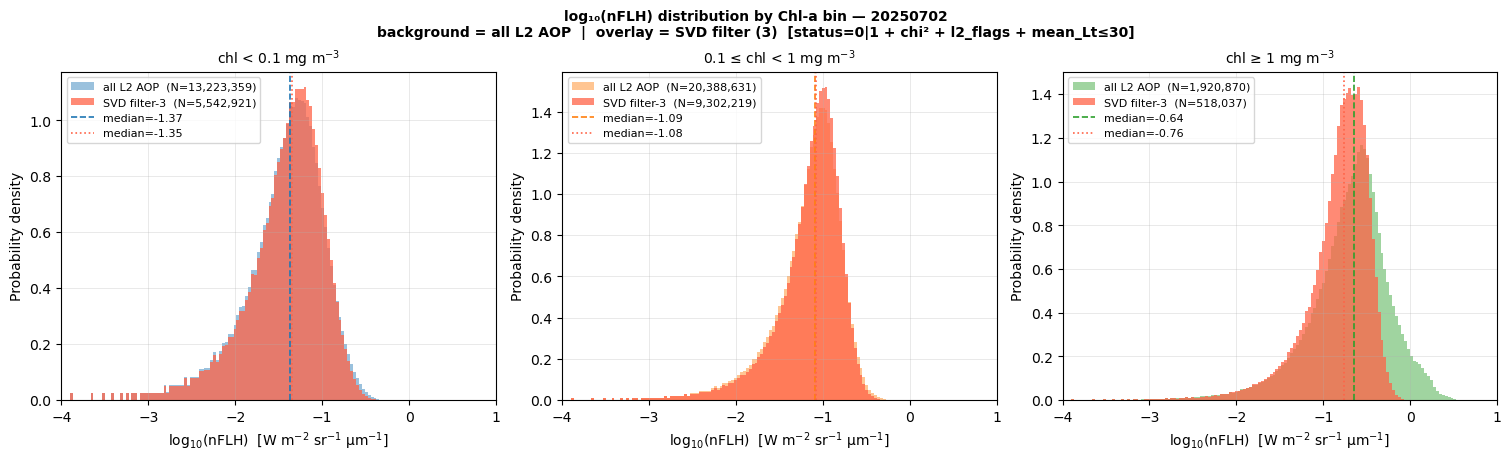

In [37]:
# ── log(nFLH) distributions binned by Chlorophyll-a ─────────────────────────
# Background : all L2 AOP + L2 BGC V3.1 granules matching DATE.
# Overlay    : SVD pixels passing filter (3) from §1 (mask_full).
# Uses match_bgc / L2BGC from the config cell; requires mask_full from filter PDF cell.

# ── collect all valid (nFLH, chlor_a) pairs ──────────────────────────────────
nflh_all = []
chl_all  = []

for gid, l2_path in sorted(l2aop_idx.items()):
    if not gid.startswith(DATE):
        continue
    bgc_path = match_bgc(gid)
    if bgc_path is None:
        print(f"  {gid}: no BGC file — skipped")
        continue

    with nc.Dataset(l2_path, "r") as ds_l2:
        nflh_raw = np.ma.filled(
            ds_l2["geophysical_data/nflh"][:], np.nan
        ).ravel().astype(np.float32)

    with nc.Dataset(bgc_path, "r") as ds_bgc:
        chl_raw = np.ma.filled(
            ds_bgc["geophysical_data/chlor_a"][:], np.nan
        ).ravel().astype(np.float32)

    nflh_all.append(nflh_raw)
    chl_all.append(chl_raw)

nflh_flat = np.concatenate(nflh_all)
chl_flat  = np.concatenate(chl_all)

# ── background: both products finite and nFLH > 0 ────────────────────────────
valid_bg = (
    np.isfinite(nflh_flat) & (nflh_flat > 0) &
    np.isfinite(chl_flat)  & (chl_flat  > 0)
)
log_nflh_bg = np.log10(nflh_flat[valid_bg])
chl_bg      = chl_flat[valid_bg]
print(f"Background pixels (nFLH>0, chl>0): {valid_bg.sum():,} / {len(valid_bg):,}")

# ── overlay: SVD pixels passing filter (3) — extract nFLH+chl via source indices
# Loops svd_files in the SAME ORDER as cell 7 so indices align with mask_full.
nflh_svd_all = []
chl_svd_all  = []

for svd_path in svd_files:
    m_re  = SVD_RE.match(os.path.basename(svd_path))
    gid   = m_re.group(1)
    l2_path  = match_l2(gid)
    bgc_path = match_bgc(gid)

    with nc.Dataset(svd_path, "r") as ds:
        n_scan   = ds.dimensions["scans"].size
        n_pix    = ds.dimensions["pixels"].size
        src_scan = np.array(ds["source_scan_index"][:]) - 1   # 0-based
        src_pix  = np.array(ds["source_pixel_index"][:]) - 1

    n_total = n_scan * n_pix

    if l2_path:
        with nc.Dataset(l2_path, "r") as ds_l2:
            nflh_g = np.ma.filled(
                ds_l2["geophysical_data/nflh"][src_scan, :][:, src_pix], np.nan
            ).ravel().astype(np.float32)
    else:
        nflh_g = np.full(n_total, np.nan, dtype=np.float32)

    if bgc_path:
        with nc.Dataset(bgc_path, "r") as ds_bgc:
            chl_g = np.ma.filled(
                ds_bgc["geophysical_data/chlor_a"][src_scan, :][:, src_pix], np.nan
            ).ravel().astype(np.float32)
    else:
        chl_g = np.full(n_total, np.nan, dtype=np.float32)

    nflh_svd_all.append(nflh_g)
    chl_svd_all.append(chl_g)

nflh_svd_flat = np.concatenate(nflh_svd_all)
chl_svd_flat  = np.concatenate(chl_svd_all)

# apply filter (3) mask from cell 7 + require nFLH > 0 and chl > 0
valid_svd = (
    mask_full &
    np.isfinite(nflh_svd_flat) & (nflh_svd_flat > 0) &
    np.isfinite(chl_svd_flat)  & (chl_svd_flat  > 0)
)
log_nflh_svd = np.log10(nflh_svd_flat[valid_svd])
chl_svd      = chl_svd_flat[valid_svd]
print(f"SVD filter-3 pixels (nFLH>0, chl>0): {valid_svd.sum():,}")

# ── 3 Chl bins ────────────────────────────────────────────────────────────────
bins_def = [
    (chl_bg < 0.1,                    chl_svd < 0.1,
     r"chl < 0.1 mg m$^{-3}$",        "C0"),
    ((chl_bg >= 0.1) & (chl_bg < 1),  (chl_svd >= 0.1) & (chl_svd < 1),
     r"0.1 ≤ chl < 1 mg m$^{-3}$",    "C1"),
    (chl_bg >= 1.0,                   chl_svd >= 1.0,
     r"chl ≥ 1 mg m$^{-3}$",          "C2"),
]

log_bins = np.linspace(-4, 1, 150)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
fig.suptitle(
    f"log₁₀(nFLH) distribution by Chl-a bin — {DATE}\n"
    r"background = all L2 AOP  |  overlay = SVD filter (3)  "
    r"[status=0|1 + chi² + l2_flags + mean_Lt≤30]",
    fontsize=10, fontweight="bold",
)

for ax, (m_bg, m_svd, label, color) in zip(axes, bins_def):
    bg_vals  = log_nflh_bg[m_bg]
    svd_vals = log_nflh_svd[m_svd]

    ax.hist(bg_vals,  bins=log_bins, density=True, alpha=0.45,
            color=color, label=f"all L2 AOP  (N={len(bg_vals):,})")
    if len(svd_vals):
        ax.hist(svd_vals, bins=log_bins, density=True, alpha=0.75,
                color="tomato", label=f"SVD filter-3  (N={len(svd_vals):,})")

    # dashed medians
    for vals, c, ls in [(bg_vals, color, "--"), (svd_vals, "tomato", ":")]:
        if len(vals):
            ax.axvline(np.median(vals), color=c, lw=1.2, ls=ls,
                       label=f"median={np.median(vals):.2f}")

    ax.set_title(label, fontsize=10)
    ax.set_xlabel(r"log$_{10}$(nFLH)  [W m$^{-2}$ sr$^{-1}$ µm$^{-1}$]", fontsize=10)
    ax.set_ylabel("Probability density", fontsize=10)
    ax.set_xlim(log_bins[0], log_bins[-1])
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

plt.show()
